<a href="https://colab.research.google.com/github/parth-electron/All-Projects/blob/main/Cart-Pole%20RL%20agent%20Training/Assignmentx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu
Starting DQN training on CartPole-v1...

Episode   10 | Reward:   23.0 | Avg(last 10):   17.5 | Epsilon: 0.892
Episode   20 | Reward:   24.0 | Avg(last 20):   18.0 | Epsilon: 0.791
Episode   30 | Reward:   21.0 | Avg(last 30):   22.6 | Epsilon: 0.644
Episode   40 | Reward:   12.0 | Avg(last 40):   21.6 | Epsilon: 0.571
Episode   50 | Reward:   30.0 | Avg(last 50):   21.0 | Epsilon: 0.507
Episode   60 | Reward:   33.0 | Avg(last 60):   22.6 | Epsilon: 0.416
Episode   70 | Reward:    9.0 | Avg(last 70):   23.1 | Epsilon: 0.353
Episode   80 | Reward:   18.0 | Avg(last 80):   22.6 | Epsilon: 0.314
Episode   90 | Reward:   25.0 | Avg(last 90):   21.8 | Epsilon: 0.285
Episode  100 | Reward:   12.0 | Avg(last 100):   21.3 | Epsilon: 0.257
Episode  110 | Reward:   14.0 | Avg(last 100):   21.7 | Epsilon: 0.226
Episode  120 | Reward:   47.0 | Avg(last 100):   25.1 | Epsilon: 0.165
Episode  130 | Reward:  130.0 | Avg(last 100):   34.8 | Epsilon: 0.081
Episode  140 | Reward:  171

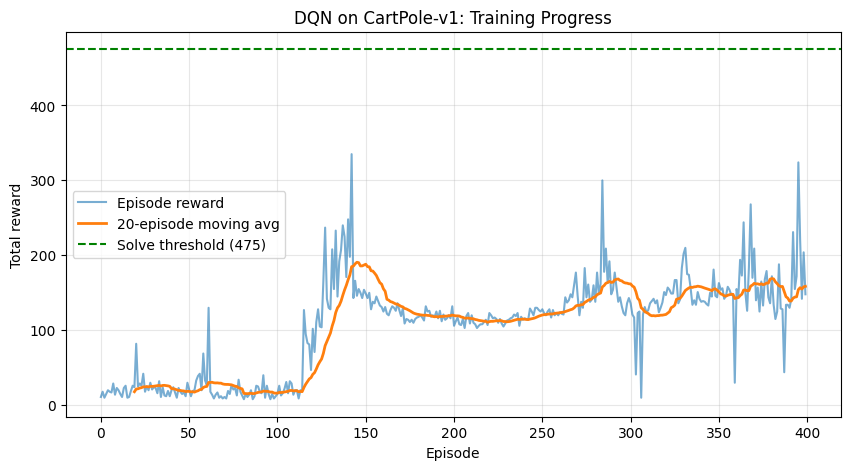


Running greedy evaluation over 20 episodes...
Evaluation scores: [231.0, 205.0, 307.0, 252.0, 278.0, 319.0, 262.0, 231.0, 415.0, 263.0, 246.0, 266.0, 233.0, 297.0, 370.0, 245.0, 264.0, 190.0, 268.0, 366.0]
Average evaluation score: 275.40 (std: 55.20, max: 415.0)

Results saved to: cartpole_results/run_20260723_064110
  - Model weights   : cartpole_results/run_20260723_064110/dqn_cartpole.pth
  - Episode rewards : cartpole_results/run_20260723_064110/episode_rewards.csv
  - Eval scores     : cartpole_results/run_20260723_064110/eval_scores.csv
  - Training plot   : cartpole_results/run_20260723_064110/training_curve.png
  - Summary         : cartpole_results/run_20260723_064110/summary.txt


In [2]:
"""
CartPole-v1 solved with Deep Q-Network (DQN)
=============================================
Run this entire file in a single Google Colab cell (or as a script).
Everything needed (installs, imports, training, evaluation, plotting)
is contained in this one file. No external requirements.txt needed.

Usage in Colab:
    1. Paste this whole file into a cell.
    2. Run it. It will install dependencies, train the agent,
       print progress, plot the reward curve, and run a final
       evaluation printing the average score over 20 episodes.
"""

# ----------------------------------------------------------------------
# 0. Install dependencies (safe to run multiple times / already installed)
# ----------------------------------------------------------------------
import subprocess
import sys

def _pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for _pkg in ["gymnasium[classic_control]", "torch", "numpy", "matplotlib"]:
    try:
        _pip_install(_pkg)
    except Exception as e:
        print(f"Warning: could not install {_pkg}: {e}")

# ----------------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------------
import random
import math
from collections import deque, namedtuple

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import gymnasium as gym

# ----------------------------------------------------------------------
# 2. Reproducibility & device
# ----------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ----------------------------------------------------------------------
# 3. Q-Network
# ----------------------------------------------------------------------
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x):
        return self.net(x)


# ----------------------------------------------------------------------
# 4. Replay Buffer
# ----------------------------------------------------------------------
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))

    def __len__(self):
        return len(self.buffer)


# ----------------------------------------------------------------------
# 5. DQN Agent
# ----------------------------------------------------------------------
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.action_dim = action_dim

        self.policy_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=1e-3)
        self.buffer = ReplayBuffer()

        self.gamma = 0.99
        self.batch_size = 64
        self.min_buffer_size = 1000

        self.eps_start = 1.0
        self.eps_end = 0.02
        self.eps_decay = 1500  # steps
        self.steps_done = 0

        self.target_update_every = 500  # steps
        self.update_count = 0

    def epsilon(self):
        return self.eps_end + (self.eps_start - self.eps_end) * math.exp(
            -1.0 * self.steps_done / self.eps_decay
        )

    def select_action(self, state, greedy=False):
        eps = self.epsilon()
        self.steps_done += 1
        if (not greedy) and random.random() < eps:
            return random.randrange(self.action_dim)
        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            q_values = self.policy_net(state_t)
            return int(torch.argmax(q_values, dim=1).item())

    def store(self, *args):
        self.buffer.push(*args)

    def train_step(self):
        if len(self.buffer) < max(self.batch_size, self.min_buffer_size):
            return None

        batch = self.buffer.sample(self.batch_size)

        states = torch.tensor(np.array(batch.state), dtype=torch.float32, device=device)
        actions = torch.tensor(batch.action, dtype=torch.int64, device=device).unsqueeze(1)
        rewards = torch.tensor(batch.reward, dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=device)
        dones = torch.tensor(batch.done, dtype=torch.float32, device=device).unsqueeze(1)

        q_values = self.policy_net(states).gather(1, actions)

        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(1, keepdim=True)[0]
            target = rewards + self.gamma * next_q_values * (1 - dones)

        loss = nn.functional.smooth_l1_loss(q_values, target)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10)
        self.optimizer.step()

        self.update_count += 1
        if self.update_count % self.target_update_every == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return loss.item()


# ----------------------------------------------------------------------
# 6. Training loop
# ----------------------------------------------------------------------
def train(num_episodes=400, max_steps=500, solve_score=475.0, solve_window=100):
    env = gym.make("CartPole-v1")
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = DQNAgent(state_dim, action_dim)

    episode_rewards = []
    recent_rewards = deque(maxlen=solve_window)
    solved_at = None

    for episode in range(1, num_episodes + 1):
        state, _ = env.reset(seed=SEED + episode)
        total_reward = 0.0

        for t in range(max_steps):
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.store(state, action, reward, next_state, float(done))
            agent.train_step()

            state = next_state
            total_reward += reward

            if done:
                break

        episode_rewards.append(total_reward)
        recent_rewards.append(total_reward)
        avg_recent = np.mean(recent_rewards)

        if episode % 10 == 0:
            print(
                f"Episode {episode:4d} | Reward: {total_reward:6.1f} | "
                f"Avg(last {len(recent_rewards)}): {avg_recent:6.1f} | "
                f"Epsilon: {agent.epsilon():.3f}"
            )

        if solved_at is None and len(recent_rewards) == solve_window and avg_recent >= solve_score:
            solved_at = episode
            print(f"\nSolved! Environment solved in {episode} episodes "
                  f"(avg reward {avg_recent:.1f} over last {solve_window} episodes).\n")
            break

    env.close()
    return agent, episode_rewards, solved_at


# ----------------------------------------------------------------------
# 7. Evaluation
# ----------------------------------------------------------------------
def evaluate(agent, num_episodes=20, max_steps=500):
    env = gym.make("CartPole-v1")
    scores = []

    for episode in range(num_episodes):
        state, _ = env.reset(seed=1000 + episode)
        total_reward = 0.0
        for t in range(max_steps):
            action = agent.select_action(state, greedy=True)
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            if terminated or truncated:
                break
        scores.append(total_reward)

    env.close()
    return scores


# ----------------------------------------------------------------------
# 8. Plotting
# ----------------------------------------------------------------------
def plot_rewards(rewards):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards, label="Episode reward", alpha=0.6)

    if len(rewards) >= 20:
        window = 20
        moving_avg = np.convolve(rewards, np.ones(window) / window, mode="valid")
        plt.plot(range(window - 1, len(rewards)), moving_avg, label=f"{window}-episode moving avg", linewidth=2)

    plt.axhline(y=475, color="green", linestyle="--", label="Solve threshold (475)")
    plt.xlabel("Episode")
    plt.ylabel("Total reward")
    plt.title("DQN on CartPole-v1: Training Progress")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# ----------------------------------------------------------------------
# 9. Save results (model checkpoint, reward history CSV, plot image)
# ----------------------------------------------------------------------
def save_results(agent, reward_history, eval_scores, out_dir="cartpole_results"):
    """
    Saves everything needed to inspect or reuse a training run:
      - policy_net weights (.pth)
      - per-episode rewards (.csv)
      - evaluation scores (.csv)
      - training curve (.png)
      - a short summary (.txt)
    In Colab, files are written to the local runtime disk. To persist them,
    either download via files.download(...) (uncomment below) or mount Drive.
    """
    import os
    import csv
    from datetime import datetime

    os.makedirs(out_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = os.path.join(out_dir, f"run_{timestamp}")
    os.makedirs(run_dir, exist_ok=True)

    # 1) Model weights
    model_path = os.path.join(run_dir, "dqn_cartpole.pth")
    torch.save(agent.policy_net.state_dict(), model_path)

    # 2) Episode rewards CSV
    rewards_path = os.path.join(run_dir, "episode_rewards.csv")
    with open(rewards_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["episode", "reward"])
        for i, r in enumerate(reward_history, start=1):
            writer.writerow([i, r])

    # 3) Evaluation scores CSV
    eval_path = os.path.join(run_dir, "eval_scores.csv")
    with open(eval_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["eval_episode", "score"])
        for i, s in enumerate(eval_scores, start=1):
            writer.writerow([i, s])

    # 4) Training curve image
    plot_path = os.path.join(run_dir, "training_curve.png")
    plt.figure(figsize=(10, 5))
    plt.plot(reward_history, label="Episode reward", alpha=0.6)
    if len(reward_history) >= 20:
        window = 20
        moving_avg = np.convolve(reward_history, np.ones(window) / window, mode="valid")
        plt.plot(range(window - 1, len(reward_history)), moving_avg,
                  label=f"{window}-episode moving avg", linewidth=2)
    plt.axhline(y=475, color="green", linestyle="--", label="Solve threshold (475)")
    plt.xlabel("Episode")
    plt.ylabel("Total reward")
    plt.title("DQN on CartPole-v1: Training Progress")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.close()

    # 5) Summary text file
    summary_path = os.path.join(run_dir, "summary.txt")
    with open(summary_path, "w") as f:
        f.write("CartPole-v1 DQN Training Summary\n")
        f.write("================================\n")
        f.write(f"Timestamp: {timestamp}\n")
        f.write(f"Episodes trained: {len(reward_history)}\n")
        f.write(f"Final 100-episode avg reward: {np.mean(reward_history[-100:]):.2f}\n")
        f.write(f"Evaluation (greedy) avg score: {np.mean(eval_scores):.2f}\n")
        f.write(f"Evaluation (greedy) std: {np.std(eval_scores):.2f}\n")
        f.write(f"Evaluation (greedy) max: {np.max(eval_scores):.1f}\n")

    print(f"\nResults saved to: {run_dir}")
    print(f"  - Model weights   : {model_path}")
    print(f"  - Episode rewards : {rewards_path}")
    print(f"  - Eval scores     : {eval_path}")
    print(f"  - Training plot   : {plot_path}")
    print(f"  - Summary         : {summary_path}")

    # Optional: uncomment to auto-download the whole folder as a zip in Colab
    # import shutil
    # from google.colab import files
    # zip_path = shutil.make_archive(run_dir, "zip", run_dir)
    # files.download(zip_path)

    return run_dir


# ----------------------------------------------------------------------
# 10. Main
# ----------------------------------------------------------------------
if __name__ == "__main__":
    print("Starting DQN training on CartPole-v1...\n")

    trained_agent, reward_history, solved_episode = train(
        num_episodes=400,
        max_steps=500,
        solve_score=475.0,
        solve_window=100,
    )

    print("\nTraining finished.")
    if solved_episode:
        print(f"Environment considered SOLVED at episode {solved_episode}.")
    else:
        print("Environment was not formally 'solved' within the episode budget, "
              "but the agent may still perform well. Check the plot / eval scores.")

    plot_rewards(reward_history)

    print("\nRunning greedy evaluation over 20 episodes...")
    eval_scores = evaluate(trained_agent, num_episodes=20, max_steps=500)
    print(f"Evaluation scores: {eval_scores}")
    print(f"Average evaluation score: {np.mean(eval_scores):.2f} "
          f"(std: {np.std(eval_scores):.2f}, max: {np.max(eval_scores):.1f})")

    save_results(trained_agent, reward_history, eval_scores)